In [1]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import sys
import types
from pathlib import Path
from functools import partial

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

sys.path.append("src")
from entropy_pruning import (
    AttentionForecaster,
    UNILoRAClassifier,
    UNILoRAWithForecasterPruning,
    build_loaders,
    set_seed,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/vcivale/miniconda3/envs/entropy_pruning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
PRUNE_LAYER = 2
KEEP_RATIO  = 0.1
SEED        = 42

CKPT_ROOT = Path("/raid/DATASETS/checkpoints-Attention-Pruning")
DATA_DIR  = "/raid/DATASETS/NCT-CRC-HE/"
DS_NAME   = "NCT-CRC-HE"

# Checkpoint paths
CKPT_CLASSIFIER  = CKPT_ROOT / f"{DS_NAME}/uni_finetuned/best_model.pt"
CKPT_FORECASTER  = CKPT_ROOT / f"{DS_NAME}/forecaster/forecaster_src02_tgt23.pt"
CKPT_FINETUNED   = CKPT_ROOT / f"{DS_NAME}/pruned_finetuned/best_prune_layer2_keep10.pt"
CKPT_CROPR       = CKPT_ROOT / f"{DS_NAME}/uni_cropr/best_model.pt"
CKPT_DYNAMICVIT  = CKPT_ROOT / f"{DS_NAME}/uni_dynamicvit/dynamicvit_checkpoint.pt"
CKPT_DYNAMICVIT_PRED = CKPT_ROOT / f"{DS_NAME}/uni_dynamicvit/best_predictors.pt"
CKPT_EVIT        = CKPT_ROOT / f"{DS_NAME}/uni_evit/best_model.pt"

set_seed(SEED)

# Verify all checkpoints exist
for name, path in [
    ("classifier", CKPT_CLASSIFIER), ("forecaster", CKPT_FORECASTER),
    ("finetuned", CKPT_FINETUNED), ("cropr", CKPT_CROPR),
    ("dynamicvit", CKPT_DYNAMICVIT), ("dynamicvit_pred", CKPT_DYNAMICVIT_PRED),
    ("evit", CKPT_EVIT),
]:
    print(f"  {name}: {path}  (exists={path.exists()})")

  classifier: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_finetuned/best_model.pt  (exists=True)
  forecaster: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/forecaster/forecaster_src02_tgt23.pt  (exists=True)
  finetuned: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/pruned_finetuned/best_prune_layer2_keep10.pt  (exists=True)
  cropr: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_cropr/best_model.pt  (exists=True)
  dynamicvit: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_dynamicvit/dynamicvit_checkpoint.pt  (exists=True)
  dynamicvit_pred: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_dynamicvit/best_predictors.pt  (exists=True)
  evit: /raid/DATASETS/checkpoints-Attention-Pruning/NCT-CRC-HE/uni_evit/best_model.pt  (exists=True)


In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
loaders = build_loaders(data_dir=DATA_DIR, img_size=224, batch_size=64, num_workers=4)
n_classes = loaders.n_classes
class_names = loaders.class_names
print(f"Classes ({n_classes}): {class_names}")
print(f"Test set size: {len(loaders.test_loader.dataset)}")

Classes (9): ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Test set size: 7180


In [5]:
# ── Helper: collect predictions ───────────────────────────────────────────────
@torch.no_grad()
def collect_predictions(model, loader, device):
    """Run inference and return (y_pred, y_true) as numpy arrays."""
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(device))
        all_preds.append(logits.argmax(-1).cpu())
        all_labels.append(labels)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return y_pred, y_true


def per_class_metrics(y_true, y_pred, class_names):
    """Return a DataFrame with per-class precision, recall, F1, support."""
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    acc_per_class = []
    for i in range(len(class_names)):
        mask = y_true == i
        acc_per_class.append(float((y_pred[mask] == i).mean()) if mask.sum() > 0 else 0.0)

    return pd.DataFrame({
        "class": class_names,
        "accuracy": acc_per_class,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": sup.astype(int),
    })

## 1. Baseline (UNI + LoRA, no pruning)

In [6]:
baseline = UNILoRAClassifier(n_classes).to(device)
baseline.load_state_dict(torch.load(CKPT_CLASSIFIER, map_location=device), strict=False)
y_pred_baseline, y_true = collect_predictions(baseline, loaders.test_loader, device)
df_baseline = per_class_metrics(y_true, y_pred_baseline, class_names)
df_baseline["method"] = "Baseline"
print(f"Baseline — acc={float((y_pred_baseline == y_true).mean()):.4f}")
del baseline; torch.cuda.empty_cache()
df_baseline

Baseline — acc=0.8490


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.982063,1.000000,0.982063,0.990950,1338,Baseline
1,BACK,0.083825,1.000000,0.083825,0.154684,847,Baseline
2,DEB,0.997050,0.298323,0.997050,0.459239,339,Baseline
3,LYM,0.981073,1.000000,0.981073,0.990446,634,Baseline
4,MUC,0.972947,0.995059,0.972947,0.983879,1035,Baseline
5,MUS,0.670608,0.902273,0.670608,0.769380,592,Baseline
6,NORM,1.000000,0.988000,1.000000,0.993964,741,Baseline
7,STR,0.926366,0.662139,0.926366,0.772277,421,Baseline
8,TUM,0.986212,0.973579,0.986212,0.979855,1233,Baseline


## 2. Ours — Entropy Pruning (Stage 3, finetuned)

In [7]:
# Load forecaster (shared with ours model)
forecaster = AttentionForecaster(embed_dim=1024, hidden=256, n_heads=4, n_layers=2, dropout=0.1).to(device)
forecaster.load_state_dict(torch.load(CKPT_FORECASTER, map_location=device))
forecaster.eval()
for p in forecaster.parameters():
    p.requires_grad_(False)

# Stage 3 pruned + finetuned
ours = UNILoRAWithForecasterPruning(
    n_classes=n_classes, forecaster=forecaster,
    prune_layer=PRUNE_LAYER, keep_ratio=KEEP_RATIO,
).to(device)
ours.load_state_dict(torch.load(CKPT_FINETUNED, map_location=device), strict=False)
y_pred_ours, _ = collect_predictions(ours, loaders.test_loader, device)
df_ours = per_class_metrics(y_true, y_pred_ours, class_names)
df_ours["method"] = "Ours"
print(f"Ours — acc={float((y_pred_ours == y_true).mean()):.4f}")
del ours; torch.cuda.empty_cache()
df_ours

Ours — acc=0.9046


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.967862,0.993098,0.967862,0.980318,1338,Ours
1,BACK,0.657615,1.000000,0.657615,0.793447,847,Ours
2,DEB,0.973451,0.518053,0.973451,0.676230,339,Ours
3,LYM,0.946372,0.990099,0.946372,0.967742,634,Ours
4,MUC,0.984541,0.940037,0.984541,0.961774,1035,Ours
5,MUS,0.728041,0.899791,0.728041,0.804855,592,Ours
6,NORM,0.982456,0.946684,0.982456,0.964238,741,Ours
7,STR,0.817102,0.665377,0.817102,0.733475,421,Ours
8,TUM,0.965937,0.970660,0.965937,0.968293,1233,Ours


## 3. CropR

In [8]:
from src.baselines.cropr.vision_transformer_copr import VisionTransformer as CroprVisionTransformer

# UNICroprVisionTransformer: re-creates blocks with LayerScale (init_values)
# to match UNI pre-training, exactly as done during CropR training.
class UNICroprVisionTransformer(CroprVisionTransformer):
    def __init__(self, cropr_cfg, init_values: float = 1e-5, **kwargs):
        super().__init__(cropr_cfg, **kwargs)
        dpr = [x.item() for x in torch.linspace(0, kwargs["drop_path_rate"], len(self.blocks))]
        if cropr_cfg["use_cropr"]:
            dpr[-1] = 0.0
        for blk_idx in range(len(self.blocks)):
            self.blocks[blk_idx] = __import__("timm").models.vision_transformer.Block(
                dim=self.embed_dim,
                num_heads=kwargs["num_heads"],
                qkv_bias=True,
                init_values=init_values,
                drop_path=dpr[blk_idx],
                norm_layer=partial(nn.LayerNorm, eps=1e-6),
            )

cropr_cfg = {
    "use_cropr": True,
    "pruning_rate": 8,
    "llf": False,
    "num_queries": 1,
    "num_heads": 1,
    "pre_attn_norm": False,
    "q_proj": False,
    "k_proj": False,
    "v_proj": False,
    "mlp": True,
    "mlp_ratio": 4.0,
    "training": True,
}

cropr_model = UNICroprVisionTransformer(
    cropr_cfg,
    init_values=1e-5,
    num_classes=n_classes,
    img_size=224,
    patch_size=16,
    embed_dim=1024,
    num_heads=16,
    depth=24,
    mlp_ratio=4.0,
    drop_path_rate=0.2,
    global_pool="avg",
    class_token=True,
).to(device)

ckpt_cropr = torch.load(CKPT_CROPR, map_location=device)
cropr_model.load_state_dict(ckpt_cropr, strict=True)
cropr_model.eval()

y_pred_cropr, _ = collect_predictions(cropr_model, loaders.test_loader, device)
df_cropr = per_class_metrics(y_true, y_pred_cropr, class_names)
df_cropr["method"] = "CropR"
print(f"CropR — acc={float((y_pred_cropr == y_true).mean()):.4f}")
del cropr_model; torch.cuda.empty_cache()
df_cropr

/home/vcivale/miniconda3/envs/entropy_pruning/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Cropr schedule (tokens remaining): [188, 180, 172, 164, 156, 148, 140, 132, 124, 116, 108, 100, 92, 84, 76, 68, 60, 52, 44, 36, 28, 20, 12]
CropR — acc=0.8490


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.822870,1.000000,0.822870,0.902829,1338,CropR
1,BACK,0.349469,1.000000,0.349469,0.517935,847,CropR
2,DEB,0.994100,0.359658,0.994100,0.528213,339,CropR
3,LYM,0.962145,0.993485,0.962145,0.977564,634,CropR
4,MUC,0.995169,0.995169,0.995169,0.995169,1035,CropR
5,MUS,0.765203,0.606426,0.765203,0.676624,592,CropR
6,NORM,0.997301,0.984021,0.997301,0.990617,741,CropR
7,STR,0.786223,0.692469,0.786223,0.736374,421,CropR
8,TUM,0.972425,0.981982,0.972425,0.977180,1233,CropR


## 4. DynamicViT

In [9]:
import timm
from peft import LoraConfig
from peft.tuners.lora import LoraModel

# ── Base LoRA classifier (DynamicViT-compatible) ─────────────────────────────
class UNILoRAClassifierDV(nn.Module):
    def __init__(self, n_classes, dropout=0.1):
        super().__init__()
        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True, num_classes=0,
        )
        lora_cfg = LoraConfig(
            r=8, lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],
            lora_dropout=0.1, bias="none",
        )
        self.backbone = LoraModel(backbone, lora_cfg, adapter_name="default")
        self.head = nn.Sequential(
            nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def load_ckpt(model, path, strict=False):
    state = torch.load(Path(path), map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    if isinstance(state, dict):
        state = {k.replace("module.", ""): v for k, v in state.items()}
    miss, unex = model.load_state_dict(state, strict=strict)
    if miss:
        print(f"  [WARN] {len(miss)} missing keys")
    if unex:
        print(f"  [WARN] {len(unex)} unexpected keys")
    return model


# ── PredictorLG from DynamicViT (Rao et al. 2021) ───────────────────────────
class PredictorLG(nn.Module):
    def __init__(self, embed_dim=1024):
        super().__init__()
        self.in_conv = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
        )
        self.out_conv = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, embed_dim // 4),
            nn.GELU(),
            nn.Linear(embed_dim // 4, 2),
            nn.LogSoftmax(dim=-1),
        )

    def forward(self, x, policy):
        x = self.in_conv(x)
        B, N, C = x.size()
        local_x = x[:, :, :C // 2]
        global_x = (x[:, :, C // 2:] * policy).sum(dim=1, keepdim=True) \
                   / torch.sum(policy, dim=1, keepdim=True).clamp(min=1e-6)
        x = torch.cat([local_x, global_x.expand(B, N, C // 2)], dim=-1)
        return self.out_conv(x)


# ── UNIDynamicViT wrapper ────────────────────────────────────────────────────
# Forward allineato esattamente al training notebook:
#   - Training: predictor → run_block → mask (Gumbel hard, sequenza piena)
#   - Inference: predictor → score → run_block → gather top-k (sequenza ridotta)
class UNIDynamicViT(nn.Module):
    def __init__(self, base_model, pruning_loc, keep_ratio, embed_dim=1024):
        super().__init__()
        self.backbone = base_model.backbone
        self.head = base_model.head
        self.pruning_loc = pruning_loc
        self.keep_ratio = keep_ratio
        self.predictors = nn.ModuleList([
            PredictorLG(embed_dim=embed_dim) for _ in pruning_loc
        ])

    @staticmethod
    def _run_block(blk, x):
        x_n1 = blk.norm1(x)
        B, N, C = x_n1.shape
        qkv = blk.attn.qkv(x_n1).reshape(B, N, 3, blk.attn.num_heads, -1).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        q, k = blk.attn.q_norm(q), blk.attn.k_norm(k)
        attn = (q @ k.transpose(-2, -1) * blk.attn.scale).softmax(-1)
        attn_out = (blk.attn.attn_drop(attn) @ v).transpose(1, 2).reshape(B, N, C)
        attn_out = blk.attn.proj_drop(blk.attn.proj(attn_out))
        if hasattr(blk, "ls1"):
            x = x + blk.drop_path1(blk.ls1(attn_out))
            x = x + blk.drop_path2(blk.ls2(blk.mlp(blk.norm2(x))))
        else:
            x = x + blk.drop_path1(attn_out)
            x = x + blk.drop_path2(blk.mlp(blk.norm2(x)))
        return x

    def forward(self, x):
        vit = self.backbone.model
        B = x.shape[0]
        x = vit.patch_embed(x)
        x = vit._pos_embed(x)
        x = vit.patch_drop(x)
        x = vit.norm_pre(x)

        N_patches = x.shape[1] - 1   # senza CLS
        prev_decision = torch.ones(B, N_patches, 1, dtype=x.dtype, device=x.device)
        p_count = 0

        for i, blk in enumerate(vit.blocks):
            if i in self.pruning_loc:
                spatial_x = x[:, 1:]
                pred_score = self.predictors[p_count](spatial_x, prev_decision)

                # Inference: predictor score → run block → top-k gather
                # (in training: predictor → run_block → Gumbel mask, sequenza piena)
                score = pred_score[:, :, 0].exp()   # prob keep
                num_keep = int(N_patches * self.keep_ratio[p_count])

                x = self._run_block(blk, x)


                keep_idx = score.topk(num_keep, dim=1).indices
                keep_idx_sorted = keep_idx.sort(dim=1).values

                cls_tok = x[:, :1, :]
                patches = x[:, 1:, :]
                C = patches.shape[-1]
                kept = torch.gather(patches, 1, keep_idx_sorted.unsqueeze(-1).expand(-1, -1, C))
                x = torch.cat([cls_tok, kept], dim=1)

                prev_decision = torch.gather(prev_decision, 1, keep_idx_sorted.unsqueeze(-1))

                p_count += 1
            else:
                x = self._run_block(blk, x)

        x = vit.norm(x)
        cls_repr = x[:, 1:].mean(dim=1)   # mean pool sui patch token rimasti
        return self.head(cls_repr)


# ── Load DynamicViT ──────────────────────────────────────────────────────────
dyn_ckpt = torch.load(CKPT_DYNAMICVIT, map_location=device)
if isinstance(dyn_ckpt, dict) and "cfg" in dyn_ckpt:
    dyn_cfg = dyn_ckpt["cfg"]
else:
    dyn_cfg = {"pruning_loc": [6, 12, 18], "keep_ratio": [0.7, 0.49, 0.343], "embed_dim": 1024}
print("DynamicViT cfg:", dyn_cfg)

# Build base UNILoRAClassifier and load finetuned weights
base_clf = UNILoRAClassifierDV(n_classes).to(device)
load_ckpt(base_clf, CKPT_CLASSIFIER, strict=False)

# Wrap with DynamicViT
dyn_model = UNIDynamicViT(
    base_model=base_clf,
    pruning_loc=dyn_cfg["pruning_loc"],
    keep_ratio=dyn_cfg["keep_ratio"],
    embed_dim=dyn_cfg.get("embed_dim", 1024),
).to(device)

# Load trained predictors
pred_sd = None
if isinstance(dyn_ckpt, dict) and "predictors" in dyn_ckpt:
    pred_sd = dyn_ckpt["predictors"]
elif Path(CKPT_DYNAMICVIT_PRED).exists():
    pred_sd = torch.load(CKPT_DYNAMICVIT_PRED, map_location=device)

if pred_sd is None:
    raise FileNotFoundError("DynamicViT predictors not found")

dyn_model.predictors.load_state_dict(pred_sd)
print("DynamicViT predictors loaded")

# Freeze everything
for p in dyn_model.parameters():
    p.requires_grad_(False)

dyn_model.eval()

y_pred_dyn, _ = collect_predictions(dyn_model, loaders.test_loader, device)
df_dyn = per_class_metrics(y_true, y_pred_dyn, class_names)
df_dyn["method"] = "DynamicViT"
print(f"DynamicViT — acc={float((y_pred_dyn == y_true).mean()):.4f}")
del dyn_model, base_clf; torch.cuda.empty_cache()
df_dyn

DynamicViT cfg: {'pruning_loc': [6, 12, 18], 'keep_ratio': [0.7, 0.49, 0.343], 'embed_dim': 1024}
DynamicViT predictors loaded
DynamicViT — acc=0.4522


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.507474,1.000000,0.507474,0.673277,1338,DynamicViT
1,BACK,0.002361,1.000000,0.002361,0.004711,847,DynamicViT
2,DEB,0.893805,0.272482,0.893805,0.417643,339,DynamicViT
3,LYM,0.000000,0.000000,0.000000,0.000000,634,DynamicViT
4,MUC,0.746860,0.985969,0.746860,0.849918,1035,DynamicViT
5,MUS,0.636824,0.494102,0.636824,0.556458,592,DynamicViT
6,NORM,0.952767,0.992968,0.952767,0.972452,741,DynamicViT
7,STR,0.966746,0.130074,0.966746,0.229296,421,DynamicViT
8,TUM,0.000000,0.000000,0.000000,0.000000,1233,DynamicViT


## 4b. ToMe



In [10]:
import copy
from tome.patch import timm as tome_patch_timm

# ── ToMe evaluation (inference-only, no training needed) ─────────────────────
TOME_R = 16  # token merged per block (0 = baseline)

# Riusa UNILoRAClassifierDV e load_ckpt definiti nella cella DynamicViT
baseline_for_tome = UNILoRAClassifierDV(n_classes).to(device)
load_ckpt(baseline_for_tome, CKPT_CLASSIFIER, strict=False)

if TOME_R > 0:
    # ToMe va applicato al ViT puro dentro il wrapper LoRA
    tome_patch_timm(baseline_for_tome.backbone.model, trace_source=False, prop_attn=True)
    baseline_for_tome.backbone.model.r = TOME_R
    print(f"ToMe applied with r={TOME_R}")
else:
    print("ToMe disabled (baseline)")

baseline_for_tome.eval()
for p in baseline_for_tome.parameters():
    p.requires_grad_(False)

y_pred_tome, _ = collect_predictions(baseline_for_tome, loaders.test_loader, device)
df_tome = per_class_metrics(y_true, y_pred_tome, class_names)
df_tome["method"] = "ToMe"
print(f"ToMe r={TOME_R} — acc={float((y_pred_tome == y_true).mean()):.4f}")
del baseline_for_tome; torch.cuda.empty_cache()
df_tome

ToMe applied with r=16
ToMe r=16 — acc=0.1765


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.020927,0.400000,0.020927,0.039773,1338,ToMe
1,BACK,0.722550,0.173519,0.722550,0.279835,847,ToMe
2,DEB,0.522124,0.128821,0.522124,0.206655,339,ToMe
3,LYM,0.001577,1.000000,0.001577,0.003150,634,ToMe
4,MUC,0.268599,0.302503,0.268599,0.284545,1035,ToMe
5,MUS,0.118243,0.072841,0.118243,0.090148,592,ToMe
6,NORM,0.000000,0.000000,0.000000,0.000000,741,ToMe
7,STR,0.199525,0.321839,0.199525,0.246334,421,ToMe
8,TUM,0.013788,0.253731,0.013788,0.026154,1233,ToMe


## 5. EViT

In [11]:
# EViT checkpoint is a UNILoRAClassifier trained with EViT-style CLS-attention pruning.
# At inference we apply the same pruning via hooks on the ViT blocks.

class UNILoRAWithEViTPruning(nn.Module):
    """UNILoRAClassifier with EViT-style CLS-attention token pruning at specified layers."""

    def __init__(self, n_classes, keep_rate=0.7, prune_layers=(6, 12, 18), fuse_token=True, dropout=0.1):
        super().__init__()
        import timm
        from peft import LoraConfig
        from peft.tuners.lora import LoraModel

        backbone = timm.create_model(
            "hf-hub:MahmoodLab/uni", pretrained=True,
            init_values=1e-5, dynamic_img_size=True,
        )
        lora_config = LoraConfig(
            r=8, lora_alpha=32,
            target_modules=["qkv", "proj", "fc1", "fc2"],
            lora_dropout=0.1, bias="none",
        )
        self.backbone = LoraModel(backbone, lora_config, adapter_name="default")
        self.head = nn.Sequential(nn.LayerNorm(1024), nn.Dropout(dropout), nn.Linear(1024, n_classes))
        self.keep_rate = keep_rate
        self.prune_layers = set(prune_layers)
        self.fuse_token = fuse_token

    def forward(self, x):
        model = self.backbone.model
        x = model.patch_embed(x)
        x = model._pos_embed(x)
        x = model.patch_drop(x)
        x = model.norm_pre(x)

        for i, blk in enumerate(model.blocks):
            x = blk(x)

            if i in self.prune_layers:
                B, N, C = x.shape
                left_tokens = max(1, int((N - 1) * self.keep_rate))
                if left_tokens < N - 1:
                    # Get CLS attention from the block's attention layer
                    # Re-compute attention weights for token selection
                    with torch.no_grad():
                        qkv = blk.attn.qkv(blk.norm1(x))
                        qkv = qkv.reshape(B, N, 3, blk.attn.num_heads, C // blk.attn.num_heads).permute(2, 0, 3, 1, 4)
                        q, k = qkv[0], qkv[1]
                        attn = (q @ k.transpose(-2, -1)) * (C // blk.attn.num_heads) ** -0.5
                        attn = attn.softmax(dim=-1)
                        cls_attn = attn[:, :, 0, 1:].mean(dim=1)  # [B, N-1]

                    _, idx = torch.topk(cls_attn, left_tokens, dim=1, largest=True, sorted=True)
                    index = idx.unsqueeze(-1).expand(-1, -1, C)

                    non_cls = x[:, 1:]
                    x_others = torch.gather(non_cls, dim=1, index=index)

                    if self.fuse_token:
                        # Fuse pruned tokens into an extra token
                        compl = self._complement_idx(idx, N - 1)
                        non_topk = torch.gather(non_cls, dim=1, index=compl.unsqueeze(-1).expand(-1, -1, C))
                        non_topk_attn = torch.gather(cls_attn, dim=1, index=compl)
                        extra_token = torch.sum(non_topk * non_topk_attn.unsqueeze(-1), dim=1, keepdim=True)
                        x = torch.cat([x[:, 0:1], x_others, extra_token], dim=1)
                    else:
                        x = torch.cat([x[:, 0:1], x_others], dim=1)

        x = model.norm(x)
        x = x[:, 0]  # CLS token
        return self.head(x)

    @staticmethod
    def _complement_idx(idx, N):
        """Return indices not in idx, from range [0, N)."""
        B, K = idx.shape
        all_idx = torch.arange(N, device=idx.device).unsqueeze(0).expand(B, -1)
        mask = torch.ones(B, N, device=idx.device, dtype=torch.bool)
        mask.scatter_(1, idx, False)
        compl = all_idx[mask].reshape(B, N - K)
        return compl


evit_model = UNILoRAWithEViTPruning(
    n_classes=n_classes, keep_rate=0.7,
    prune_layers={6, 12, 18}, fuse_token=True,
).to(device)
evit_model.load_state_dict(torch.load(CKPT_EVIT, map_location=device), strict=False)
evit_model.eval()

y_pred_evit, _ = collect_predictions(evit_model, loaders.test_loader, device)
df_evit = per_class_metrics(y_true, y_pred_evit, class_names)
df_evit["method"] = "EViT"
print(f"EViT — acc={float((y_pred_evit == y_true).mean()):.4f}")
del evit_model; torch.cuda.empty_cache()
df_evit

EViT — acc=0.8295


,class,accuracy,precision,recall,f1,support,method
0,ADI,0.958894,1.000000,0.958894,0.979016,1338,EViT
1,BACK,0.074380,1.000000,0.074380,0.138462,847,EViT
2,DEB,0.979351,0.452933,0.979351,0.619403,339,EViT
3,LYM,0.982650,0.996800,0.982650,0.989674,634,EViT
4,MUC,0.933333,0.986721,0.933333,0.959285,1035,EViT
5,MUS,0.682432,0.449388,0.682432,0.541918,592,EViT
6,NORM,1.000000,0.953668,1.000000,0.976285,741,EViT
7,STR,0.836105,0.640000,0.836105,0.725026,421,EViT
8,TUM,0.966748,0.937844,0.966748,0.952077,1233,EViT


## Results: Per-class comparison

In [12]:
# ── Merge all results ─────────────────────────────────────────────────────────

dfs = []
for name, var in [
    ("Baseline", "df_baseline"),
    ("Ours", "df_ours"),
    ("CropR", "df_cropr"),
    ("DynamicViT", "df_dyn"),
    ("ToMe", "df_tome"),
    ("EViT", "df_evit"),
]:
    if var in globals():
        dfs.append(globals()[var])
    else:
        print(f"[WARN] Missing {var} → {name} will not appear in plots")

if not dfs:
    raise RuntimeError("No result DataFrames available for plotting")

df_all = pd.concat(dfs, ignore_index=True)
print("[INFO] Methods in df_all:", sorted(df_all["method"].unique()))

# Pivot table for easy comparison
pivot_acc = df_all.pivot(index="class", columns="method", values="accuracy")
pivot_f1  = df_all.pivot(index="class", columns="method", values="f1")

method_order = ["Baseline", "Ours", "CropR", "DynamicViT", "ToMe", "EViT"]
pivot_acc = pivot_acc[[m for m in method_order if m in pivot_acc.columns]]
pivot_f1  = pivot_f1[[m for m in method_order if m in pivot_f1.columns]]

display(pivot_acc.round(4))
display(pivot_f1.round(4))

[INFO] Methods in df_all: ['Baseline', 'CropR', 'DynamicViT', 'EViT', 'Ours', 'ToMe']


method,Baseline,Ours,CropR,DynamicViT,ToMe,EViT
class,,,,,,
ADI,0.9821,0.9679,0.8229,0.5075,0.0209,0.9589
BACK,0.0838,0.6576,0.3495,0.0024,0.7226,0.0744
DEB,0.9971,0.9735,0.9941,0.8938,0.5221,0.9794
LYM,0.9811,0.9464,0.9621,0.0000,0.0016,0.9826
MUC,0.9729,0.9845,0.9952,0.7469,0.2686,0.9333
MUS,0.6706,0.7280,0.7652,0.6368,0.1182,0.6824
NORM,1.0000,0.9825,0.9973,0.9528,0.0000,1.0000
STR,0.9264,0.8171,0.7862,0.9667,0.1995,0.8361
TUM,0.9862,0.9659,0.9724,0.0000,0.0138,0.9667


method,Baseline,Ours,CropR,DynamicViT,ToMe,EViT
class,,,,,,
ADI,0.9910,0.9803,0.9028,0.6733,0.0398,0.9790
BACK,0.1547,0.7934,0.5179,0.0047,0.2798,0.1385
DEB,0.4592,0.6762,0.5282,0.4176,0.2067,0.6194
LYM,0.9904,0.9677,0.9776,0.0000,0.0031,0.9897
MUC,0.9839,0.9618,0.9952,0.8499,0.2845,0.9593
MUS,0.7694,0.8049,0.6766,0.5565,0.0901,0.5419
NORM,0.9940,0.9642,0.9906,0.9725,0.0000,0.9763
STR,0.7723,0.7335,0.7364,0.2293,0.2463,0.7250
TUM,0.9799,0.9683,0.9772,0.0000,0.0262,0.9521


In [13]:
df_all

,class,accuracy,precision,recall,f1,support,method
0,ADI,0.982063,1.000000,0.982063,0.990950,1338,Baseline
1,BACK,0.083825,1.000000,0.083825,0.154684,847,Baseline
2,DEB,0.997050,0.298323,0.997050,0.459239,339,Baseline
3,LYM,0.981073,1.000000,0.981073,0.990446,634,Baseline
4,MUC,0.972947,0.995059,0.972947,0.983879,1035,Baseline
5,MUS,0.670608,0.902273,0.670608,0.769380,592,Baseline
6,NORM,1.000000,0.988000,1.000000,0.993964,741,Baseline
7,STR,0.926366,0.662139,0.926366,0.772277,421,Baseline
8,TUM,0.986212,0.973579,0.986212,0.979855,1233,Baseline
9,ADI,0.967862,0.993098,0.967862,0.980318,1338,Ours


Saved -> results/thesis/per_class_f1_NCT-CRC-HE.pdf


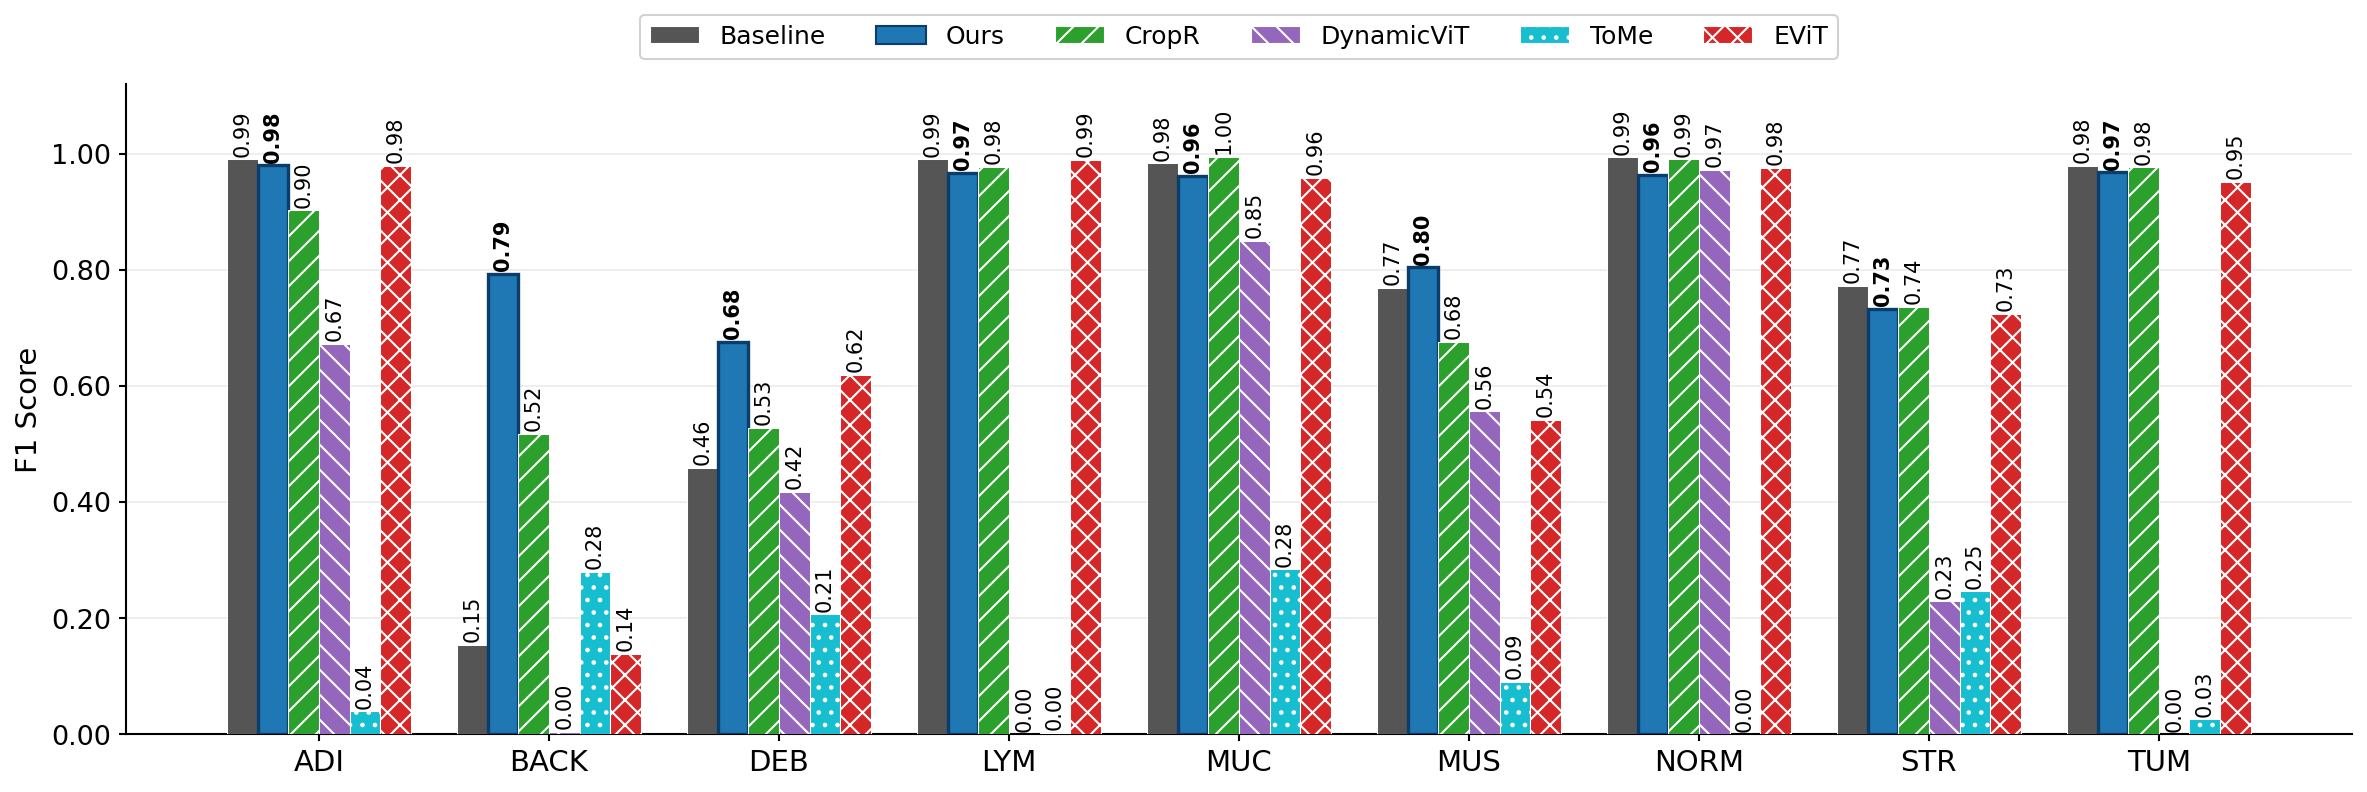

In [14]:
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

OUT = Path("results/thesis")
OUT.mkdir(parents=True, exist_ok=True)

FONT = 14

matplotlib.rcParams.update({
    "font.family":        "sans-serif",
    "font.size":          FONT,
    "axes.titlesize":     FONT,
    "axes.labelsize":     FONT,
    "xtick.labelsize":    FONT - 1,
    "ytick.labelsize":    FONT - 1,
    "legend.fontsize":    FONT - 2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.linewidth":     1.0,
    "xtick.major.width":  1.0,
    "ytick.major.width":  1.0,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "#cccccc",
    "figure.dpi":         150,
})

# Palette — consistent with thesis
C_OURS   = "#1f77b4"
C_EDGE   = "#0a3d6b"
C_GREY   = "#aec7e8"
C_RED    = "#d62728"
C_ORANGE = "#ff7f0e"
C_DARK   = "#555555"
C_GREEN  = "#2ca02c"
C_PURPLE = "#9467bd"
C_CYAN   = "#17becf"

def savepdf(fig, name: str):
    path = OUT / f"{name}.pdf"
    fig.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved -> {path}")

# ── Pretty display names for BREAKHIS classes ────────────────────────────────
BREAKHIS_LABEL_MAP = {
    "adenosis":           "Aden.",
    "fibroadenoma":       "Fibro.",
    "phyllodes_tumor":    "Phyll.",
    "tubular_adenoma":    "Tub. A.",
    "ductal_carcinoma":   "Ductal C.",
    "lobular_carcinoma":  "Lobular C.",
    "mucinous_carcinoma": "Mucinous C.",
    "papillary_carcinoma":"Papillary C.",
}

display_names = [BREAKHIS_LABEL_MAP.get(c, c) for c in class_names] if DS_NAME == "BREAKHIS" else list(class_names)

METHOD_ORDER = ["Baseline", "Ours", "CropR", "DynamicViT", "ToMe", "EViT"]
COLORS  = {
    "Baseline": C_DARK, "Ours": C_OURS, "CropR": C_GREEN,
    "DynamicViT": C_PURPLE, "ToMe": C_CYAN, "EViT": C_RED,
}
HATCHES = {
    "Baseline": "", "Ours": "", "CropR": "//",
    "DynamicViT": "\\\\", "ToMe": "..", "EViT": "xx",
}

# ── Per-class F1 grouped bar chart ───────────────────────────────────────────
methods = [m for m in METHOD_ORDER if m in pivot_f1.columns]
n_methods = len(methods)
n_classes = len(class_names)
x = np.arange(n_classes)
width = 0.8 / n_methods
offsets = np.linspace(-(n_methods - 1) / 2, (n_methods - 1) / 2, n_methods) * width

fig, ax = plt.subplots(figsize=(16, 5.5))

for i, method in enumerate(methods):
    vals = pivot_f1[method].reindex(class_names).values
    bars = ax.bar(
        x + offsets[i], vals, width,
        color=COLORS[method], hatch=HATCHES[method],
        edgecolor="white", linewidth=0.5,
        zorder=3,
    )
    if method == "Ours":
        for bar in bars:
            bar.set_edgecolor(C_EDGE)
            bar.set_linewidth(1.6)

    for bar, val in zip(bars, vals):
        fw = "bold" if method == "Ours" else "normal"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=FONT - 4, rotation=90, fontweight=fw,
        )

ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=FONT)
ax.set_ylabel("F1 Score", fontsize=FONT)

ymin = max(0, pivot_f1.min().min() - 0.15)
ax.set_ylim(ymin, 1.12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", alpha=0.25, zorder=0)

legend_handles = [
    mpatches.Patch(facecolor=COLORS[m], edgecolor=C_EDGE if m == "Ours" else "white",
                   hatch=HATCHES[m], label=m)
    for m in methods
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(legend_handles),
    fontsize=FONT - 2,
    framealpha=0.9,
)

plt.tight_layout()
savepdf(fig, f"per_class_f1_{DS_NAME}")
plt.show()

Saved -> results/thesis/per_class_acc_NCT-CRC-HE.pdf


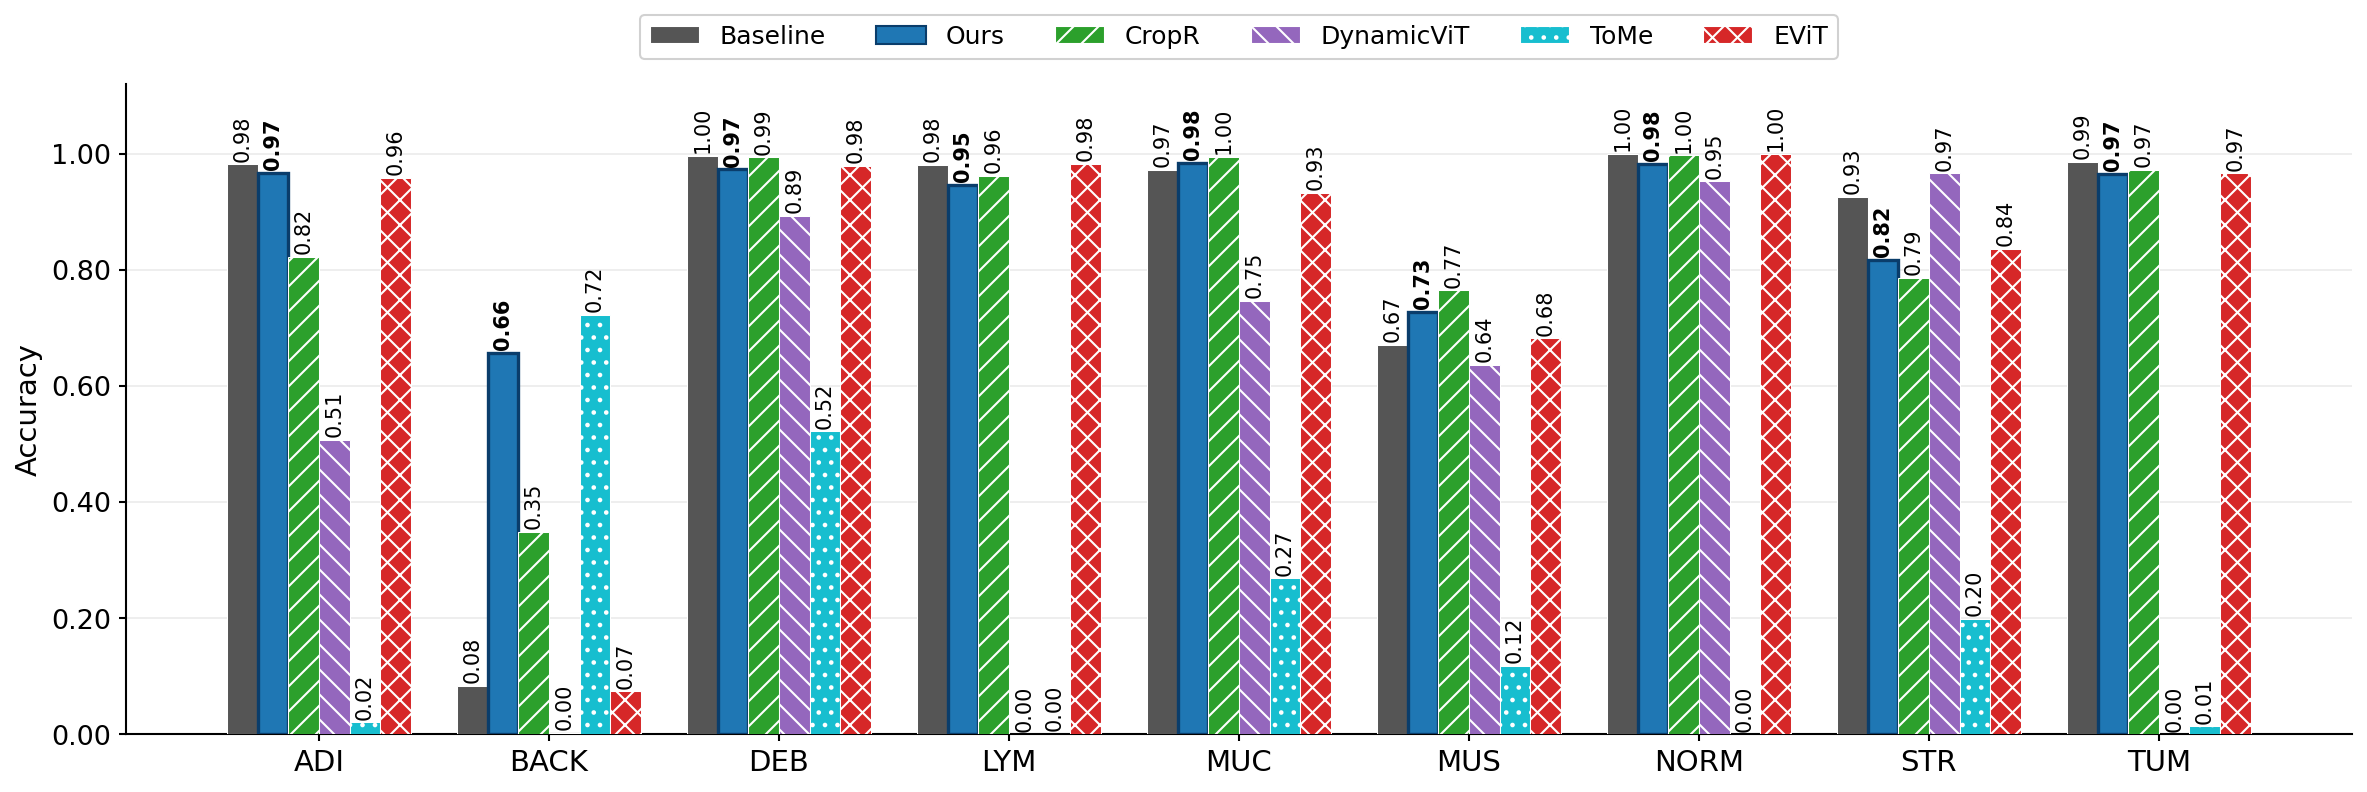

In [15]:
# ── Per-class Accuracy grouped bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5.5))

for i, method in enumerate(methods):
    vals = pivot_acc[method].reindex(class_names).values
    bars = ax.bar(
        x + offsets[i], vals, width,
        color=COLORS[method], hatch=HATCHES[method],
        edgecolor="white", linewidth=0.5,
        zorder=3,
    )
    if method == "Ours":
        for bar in bars:
            bar.set_edgecolor(C_EDGE)
            bar.set_linewidth(1.6)

    for bar, val in zip(bars, vals):
        fw = "bold" if method == "Ours" else "normal"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=FONT - 4, rotation=90, fontweight=fw,
        )

ax.set_xticks(x)
ax.set_xticklabels(display_names, fontsize=FONT)
ax.set_ylabel("Accuracy", fontsize=FONT)

ymin = max(0, pivot_acc.min().min() - 0.15)
ax.set_ylim(ymin, 1.12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="y", alpha=0.25, zorder=0)

legend_handles = [
    mpatches.Patch(facecolor=COLORS[m], edgecolor=C_EDGE if m == "Ours" else "white",
                   hatch=HATCHES[m], label=m)
    for m in methods
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(legend_handles),
    fontsize=FONT - 2,
    framealpha=0.9,
)

plt.tight_layout()
savepdf(fig, f"per_class_acc_{DS_NAME}")
plt.show()

In [16]:
pivot_f1

method,Baseline,Ours,CropR,DynamicViT,ToMe,EViT
class,,,,,,
ADI,0.990950,0.980318,0.902829,0.673277,0.039773,0.979016
BACK,0.154684,0.793447,0.517935,0.004711,0.279835,0.138462
DEB,0.459239,0.676230,0.528213,0.417643,0.206655,0.619403
LYM,0.990446,0.967742,0.977564,0.000000,0.003150,0.989674
MUC,0.983879,0.961774,0.995169,0.849918,0.284545,0.959285
MUS,0.769380,0.804855,0.676624,0.556458,0.090148,0.541918
NORM,0.993964,0.964238,0.990617,0.972452,0.000000,0.976285
STR,0.772277,0.733475,0.736374,0.229296,0.246334,0.725026
TUM,0.979855,0.968293,0.977180,0.000000,0.026154,0.952077


Saved -> results/thesis/per_class_delta_f1_NCT-CRC-HE_delta_only.pdf


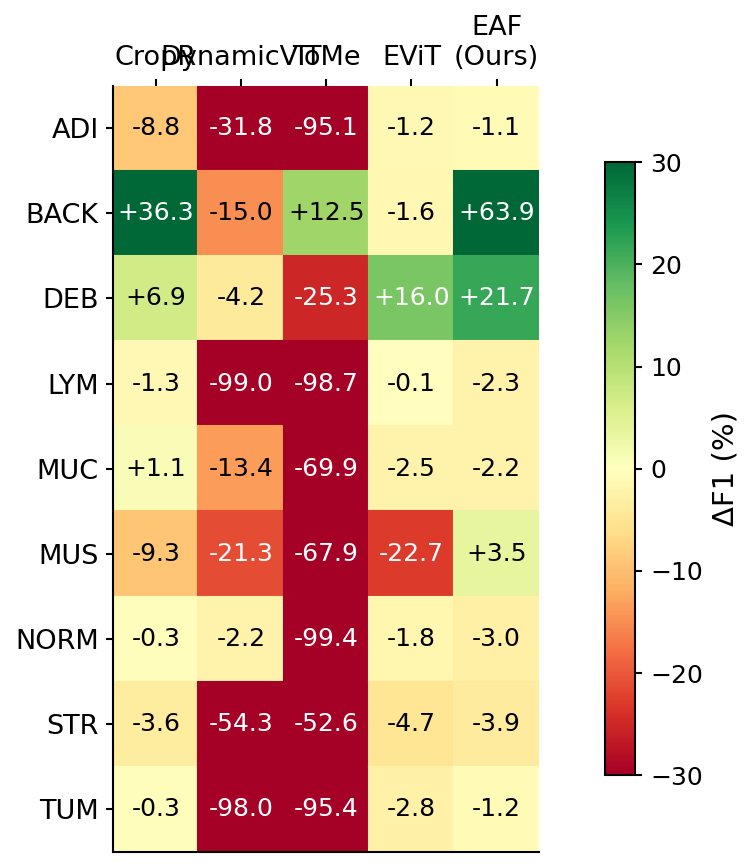

In [17]:
# ── Delta F1 vs Baseline (heatmap-style) senza Baseline ─────────────────────
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Rename method for plotting
pivot_f1 = pivot_f1.rename(columns={"Ours": "EAF"})
METHOD_ORDER = ["EAF" if m == "Ours" else m for m in METHOD_ORDER]

# Put EAF last among non-baseline methods
delta_methods = [m for m in METHOD_ORDER if m != "Baseline" and m != "EAF" and m in pivot_f1.columns]
delta_methods = delta_methods + ["EAF"]

# Compute delta vs baseline
delta_f1 = pivot_f1[delta_methods].subtract(pivot_f1["Baseline"], axis=0) * 100

# Build data matrix: only delta columns
delta_data = delta_f1.reindex(class_names).values
n_cols_delta = len(delta_methods)

fig, ax = plt.subplots(figsize=(max(10, 3 * n_cols_delta), 6))

# ── Draw delta columns with RdYlGn colormap ──────────────────────────────────
norm_delta = mcolors.TwoSlopeNorm(vmin=-30, vcenter=0, vmax=30)
cmap_delta = plt.get_cmap("RdYlGn")

for j in range(n_cols_delta):
    for i in range(n_classes):
        val = delta_data[i, j]
        color = cmap_delta(norm_delta(val))
        rect = plt.Rectangle([j - 0.5, i - 0.5], 1, 1, color=color)
        ax.add_patch(rect)

# ── Annotations for delta columns ───────────────────────────────────────────
for i in range(n_classes):
    for j in range(n_cols_delta):
        val = delta_data[i, j]
        txt_color = "white" if abs(val) > 15 else "black"
        ax.text(j, i, f"{val:+.1f}", ha="center", va="center",
                fontsize=FONT - 2, color=txt_color)

# ── Axes ─────────────────────────────────────────────────────────────────────
ax.set_xlim(-0.5, n_cols_delta - 0.5)
ax.set_ylim(n_classes - 0.5, -0.5)

x_labels = [("EAF\n(Ours)" if m == "EAF" else m) for m in delta_methods]
ax.set_xticks(range(n_cols_delta))
ax.set_xticklabels(x_labels, fontsize=FONT - 1)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.set_yticks(range(n_classes))
ax.set_yticklabels(display_names, fontsize=FONT - 1)

# ── Colorbar for delta columns ───────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap_delta, norm=norm_delta)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, label="\u0394F1 (%)", shrink=0.8, pad=0.03)
cb.ax.tick_params(labelsize=FONT - 2)

ax.set_aspect("equal")
plt.tight_layout()
savepdf(fig, f"per_class_delta_f1_{DS_NAME}_delta_only")
plt.show()

In [18]:
# ── Confusion matrices separate ──────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

predictions = {
    "Baseline": y_pred_baseline,
    "Ours": y_pred_ours,
    "CropR": y_pred_cropr,
    "DynamicViT": y_pred_dyn,
    "ToMe": y_pred_tome,
    "EViT": y_pred_evit,
}

for method, y_pred in predictions.items():
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    fig, ax = plt.subplots(figsize=(4.8, 4.8))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(display_names, rotation=45, ha="right", fontsize=FONT - 3)
    ax.set_yticklabels(display_names, fontsize=FONT - 3)
    ax.set_xlabel("Predicted", fontsize=FONT - 1)
    ax.set_ylabel("True", fontsize=FONT - 1)

    # Numeric values inside cells
    for i in range(n_classes):
        for j in range(n_classes):
            val = cm_norm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=FONT - 4, color=color)

    plt.tight_layout()
    savepdf(fig, f"confusion_matrix_{DS_NAME}_{method.lower().replace(' ', '_')}")
    plt.close(fig)

Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_baseline.pdf
Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_ours.pdf
Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_cropr.pdf
Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_dynamicvit.pdf
Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_tome.pdf
Saved -> results/thesis/confusion_matrix_NCT-CRC-HE_evit.pdf


In [19]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for method, y_pred in predictions.items():
    acc = float((y_pred == y_true).mean())
    _, _, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    summary_rows.append({"method": method, "accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted})

df_summary = pd.DataFrame(summary_rows).set_index("method").reindex(METHOD_ORDER)
df_summary["Δacc_vs_baseline"] = df_summary["accuracy"] - df_summary.loc["Baseline", "accuracy"]
df_summary["Δf1_vs_baseline"]  = df_summary["f1_macro"] - df_summary.loc["Baseline", "f1_macro"]

print(f"Global summary — {DS_NAME}\n")
display(df_summary.round(4))

# Save CSV
df_all.to_csv(f"results/per_class_{DS_NAME}.csv", index=False)
df_summary.round(4).to_csv(f"results/per_class_summary_{DS_NAME}.csv")
print(f"\nSaved -> results/per_class_{DS_NAME}.csv")
print(f"Saved -> results/per_class_summary_{DS_NAME}.csv")

Global summary — NCT-CRC-HE



,accuracy,f1_macro,f1_weighted,Δacc_vs_baseline,Δf1_vs_baseline
method,,,,,
Baseline,0.8490,0.7883,0.8334,0.0000,0.0000
EAF,NaN,NaN,NaN,NaN,NaN
CropR,0.8490,0.8114,0.8531,0.0000,0.0231
DynamicViT,0.4522,0.4115,0.4279,-0.3968,-0.3768
ToMe,0.1765,0.1307,0.1178,-0.6726,-0.6576
EViT,0.8295,0.7646,0.8051,-0.0195,-0.0237



Saved -> results/per_class_NCT-CRC-HE.csv
Saved -> results/per_class_summary_NCT-CRC-HE.csv


## 7. Heatmap: ΔF1 per classe × metodo (vs Baseline)

Saved -> results/thesis/per_class_delta_f1_heatmap_NCT-CRC-HE.pdf


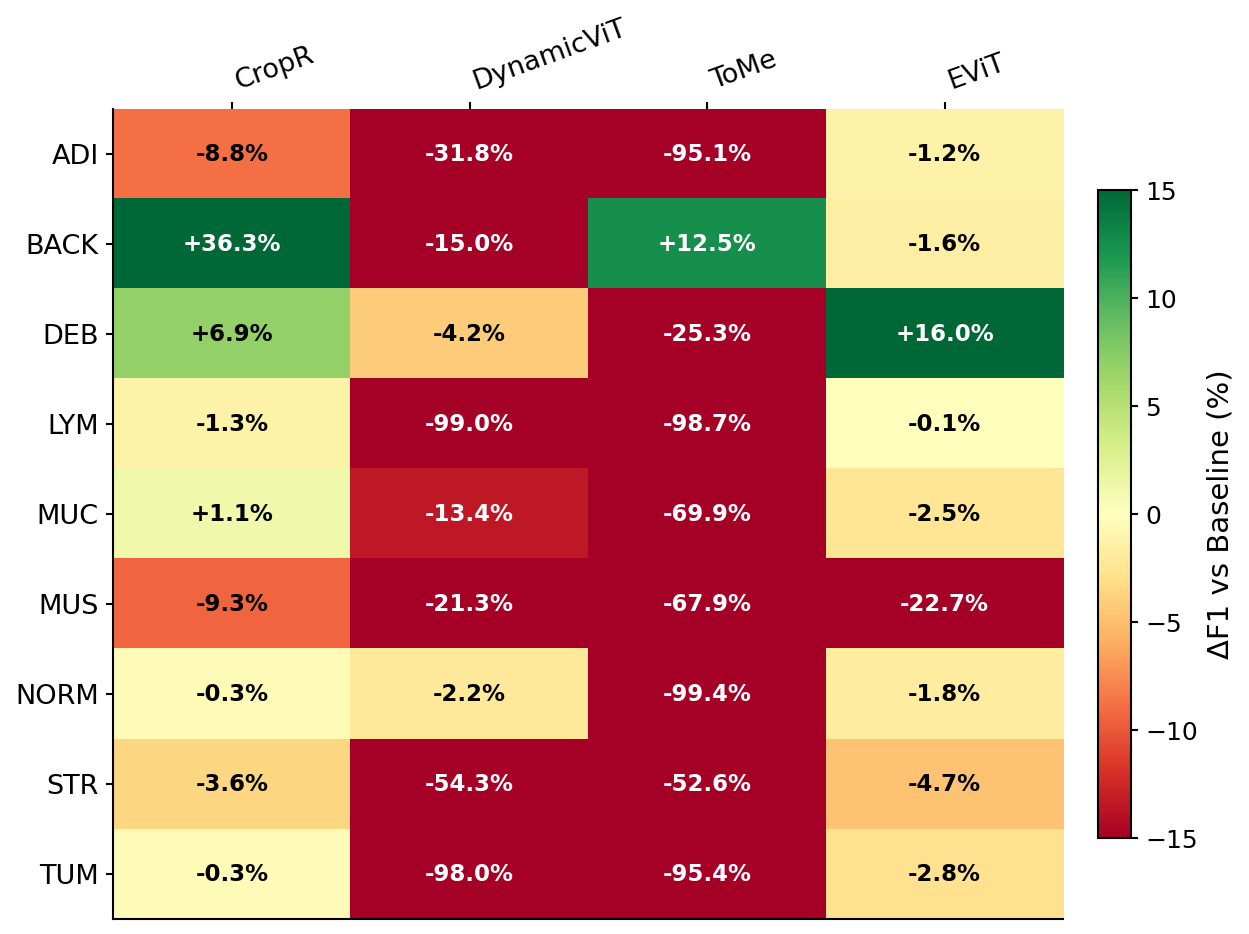

In [20]:
# ── Heatmap: ΔF1 per class × method vs Baseline ──────────────────────────────
from matplotlib.colors import TwoSlopeNorm

# Build per-class F1 for all methods
all_method_f1 = {}
for method, y_pred in predictions.items():
    _, _, f1_per_class, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    all_method_f1[method] = f1_per_class

baseline_f1 = all_method_f1["Baseline"]

# Column order: all methods except Baseline
heatmap_cols = [m for m in METHOD_ORDER if m != "Baseline" and m in all_method_f1]

# Build delta matrix (percentage)
delta_matrix = np.stack(
    [all_method_f1[col] - baseline_f1 for col in heatmap_cols], axis=1
) * 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(max(8, 2.2 * len(heatmap_cols)), max(4, 0.55 * n_classes + 1.5))
)

norm = TwoSlopeNorm(vmin=-15, vcenter=0, vmax=15)

im = ax.imshow(delta_matrix, cmap="RdYlGn", norm=norm, aspect="auto")

# X axis (methods)
x_labels = [("EAF\n(Ours)" if m == "EAF" else m) for m in heatmap_cols]
ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(x_labels, fontsize=FONT - 1, rotation=20, ha="left")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Y axis (classes)
ax.set_yticks(range(n_classes))
ax.set_yticklabels(display_names, fontsize=FONT - 1)

# Annotate cells
for row in range(n_classes):
    for col in range(len(heatmap_cols)):
        val = delta_matrix[row, col]
        abs_norm = abs(val) / 15
        text_color = "white" if abs_norm > 0.65 else "black"
        sign = "+" if val >= 0 else ""
        ax.text(col, row, f"{sign}{val:.1f}%", ha="center", va="center",
                fontsize=FONT - 3, color=text_color, fontweight="bold")

# Colorbar
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, label="\u0394F1 vs Baseline (%)", shrink=0.8, pad=0.03)
cb.ax.tick_params(labelsize=FONT - 2)

plt.tight_layout()
savepdf(fig, f"per_class_delta_f1_heatmap_{DS_NAME}")
plt.show()